<a href="https://colab.research.google.com/github/sk27110/MatStat/blob/HW2/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
from scipy.special import factorial
import matplotlib.pyplot as plt
from tqdm import tqdm

In [19]:
uniform_param = 10
exponential_param = 3

sample_size = 1000
num_iterations = 10000

In [20]:
exponents = np.arange(1, 101)
uniform_errors = []
exponential_errors = []


def power_mean(data, exponent):
    return np.mean(data ** exponent)


for k in tqdm(exponents):
    uniform_errors_k = []
    exponential_errors_k = []

    for _ in range(num_iterations):
        uniform_samples = np.random.uniform(0, uniform_param, sample_size)
        exp_samples = np.random.exponential(exponential_param, sample_size)

        theta_est = (power_mean(uniform_samples, k) * (k + 1)) ** (1 / k)
        lambda_est = (power_mean(exp_samples, k) / factorial(k)) ** (1 / k)

        uniform_errors_k.append((theta_est - uniform_param) ** 2)
        exponential_errors_k.append((lambda_est - exponential_param) ** 2)

    uniform_errors.append(np.mean(uniform_errors_k))
    exponential_errors.append(np.mean(exponential_errors_k))

100%|██████████| 100/100 [02:16<00:00,  1.36s/it]


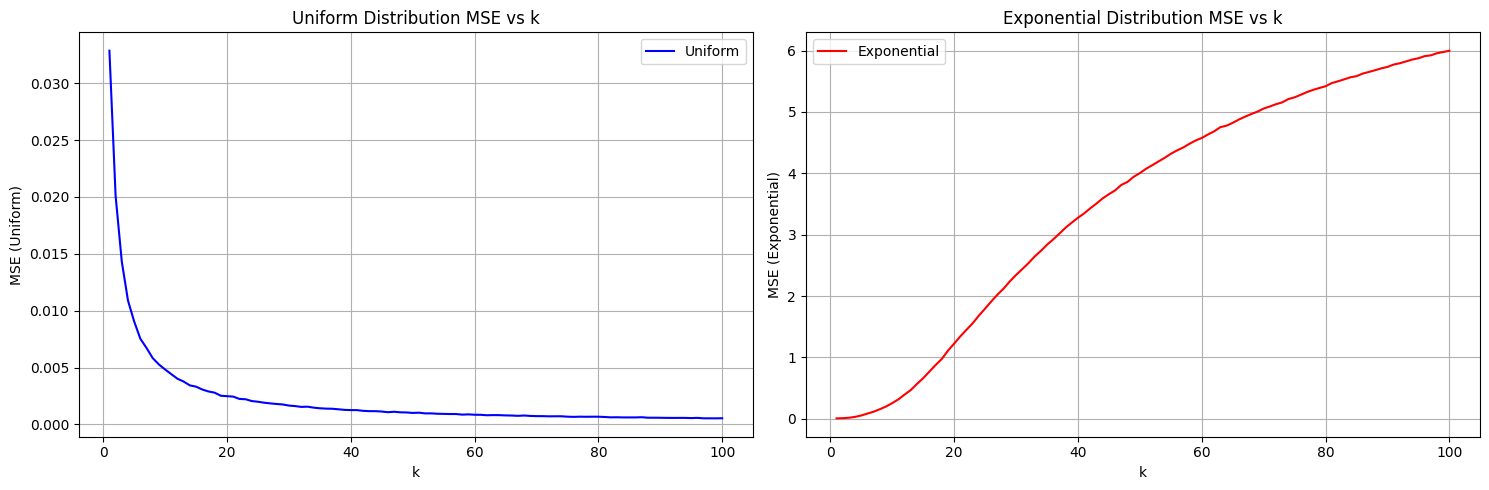

In [21]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(exponents, uniform_errors, color='blue', label='Uniform')
ax1.set_xlabel('k')
ax1.set_ylabel('MSE (Uniform)')
ax1.set_title('Uniform Distribution MSE vs k')
ax1.grid(True)
ax1.legend()


ax2.plot(exponents, exponential_errors, color='red', label='Exponential')
ax2.set_xlabel('k')
ax2.set_ylabel('MSE (Exponential)')
ax2.set_title('Exponential Distribution MSE vs k')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()